# Baseline: target = локальный минимум ±1

Все четыре индикатора оцениваются относительно локального минимума на горизонте 1 свежих публикаций ЦБ.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from fx_signal.baseline import build_baseline_frame

sns.set_theme(style='whitegrid')
HORIZON = 1
CONFIG = Path('../configs/baseline.yaml') if Path.cwd().name == 'notebooks' else Path('configs/baseline.yaml')
frame, metrics = build_baseline_frame(CONFIG, horizon=HORIZON)

## Покрытие и prevalence target

In [2]:
target_col = f'target_local_min_h{HORIZON}'
frame.groupby('currency')[target_col].agg(eligible='count', positives='sum', prevalence='mean')

,eligible,positives,prevalence
currency,,,
AMD,1886,429,0.227466
KGS,1886,428,0.226935
KZT,1886,440,0.233298
TJS,1886,424,0.224814
UZS,1886,410,0.217391


## Hit rate и lift каждого индикатора

In [3]:
metrics.sort_values(['corridor', 'lift'], ascending=[True, False]).reset_index(drop=True)

,horizon,corridor,indicator,eligible_days,signal_count,target_positives,signal_hit_rate,random_hit_rate,lift,signals_per_week
0,1,RUB->AMD,momentum,1798,251,404,0.466135,0.224694,2.074534,0.661023
1,1,RUB->AMD,level,1798,302,404,0.314570,0.224694,1.399990,0.795335
2,1,RUB->AMD,seasonality,1798,356,404,0.247191,0.224694,1.100122,0.937547
3,1,RUB->AMD,reversal,1798,87,404,0.000000,0.224694,0.000000,0.229120
4,1,RUB->KGS,momentum,1798,273,405,0.446886,0.225250,1.983955,0.718962
5,1,RUB->KGS,level,1798,361,405,0.313019,0.225250,1.389652,0.950715
6,1,RUB->KGS,seasonality,1798,387,405,0.235142,0.225250,1.043915,1.019187
7,1,RUB->KGS,reversal,1798,98,405,0.000000,0.225250,0.000000,0.258089
8,1,RUB->KZT,momentum,1798,249,420,0.497992,0.233593,2.131880,0.655756
9,1,RUB->KZT,level,1798,379,420,0.282322,0.233593,1.208607,0.998119


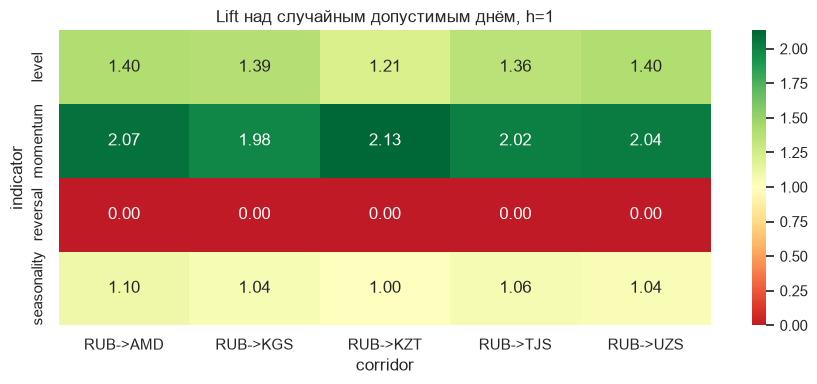

In [4]:
heatmap = metrics.pivot(index='indicator', columns='corridor', values='lift')
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(heatmap, annot=True, fmt='.2f', center=1.0, cmap='RdYlGn', ax=ax)
ax.set_title(f'Lift над случайным допустимым днём, h={HORIZON}')
fig.tight_layout()
repo_root = CONFIG.resolve().parent.parent
figures_dir = repo_root / 'reports' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figures_dir / f'baseline_lift_h{HORIZON}.png', dpi=160, bbox_inches='tight')

## Интерпретация

lift > 1 означает, что правило чаще случайного допустимого дня совпадает с выбранным local-min target. Reversal срабатывает после минимума, поэтому его низкий lift здесь нельзя считать окончательным выводом о полезности: для него нужна отдельная метрика последующего роста курса.